# Level-0 Ratio Profile And $J_\nu$ Example

This notebook shows how to:

1. Load and plot the level-0 ratio profile from `data/r_lev0_2.5au.csv` as a function of distance in km.
2. Use that ratio profile in a simple two-level statistical-equilibrium estimate for the mean radiation field `J_nu` at each grid cell.


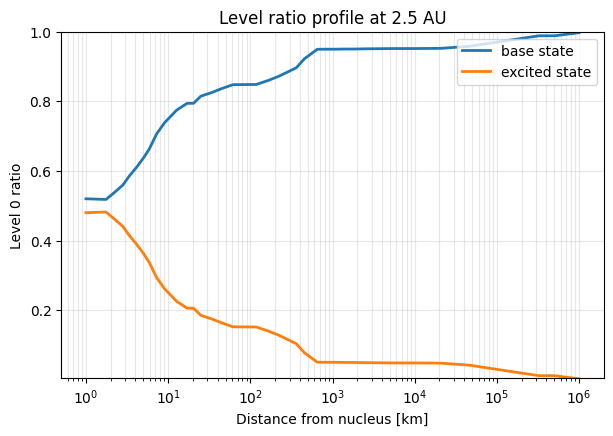

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
data_path = repo_root / "data" / "r_lev0_2.5au.csv"

profile = np.loadtxt(data_path, delimiter=",")
radius_km = profile[::-1, 0]
level0_ratio = profile[::-1, 1] + 0.4 * (1 - profile[::-1, 1])
level1_ratio=1-level0_ratio

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(radius_km, level0_ratio, lw=2, label='base state')
ax.semilogx(radius_km, level1_ratio, lw=2, label='excited state')

ax.set_ylim(0.005, 1)
ax.legend(loc="upper right")
# ax.set_xscale("log")
ax.set_xlabel("Distance from nucleus [km]")
ax.set_ylabel("Level 0 ratio")
ax.set_title("Level ratio profile at 2.5 AU")
ax.grid(True, which="both", alpha=0.3)
plt.show()


B_ul = 1.357e+12 m^2 J^-1 s^-1
B_lu = 1.357e+12 m^2 J^-1 s^-1


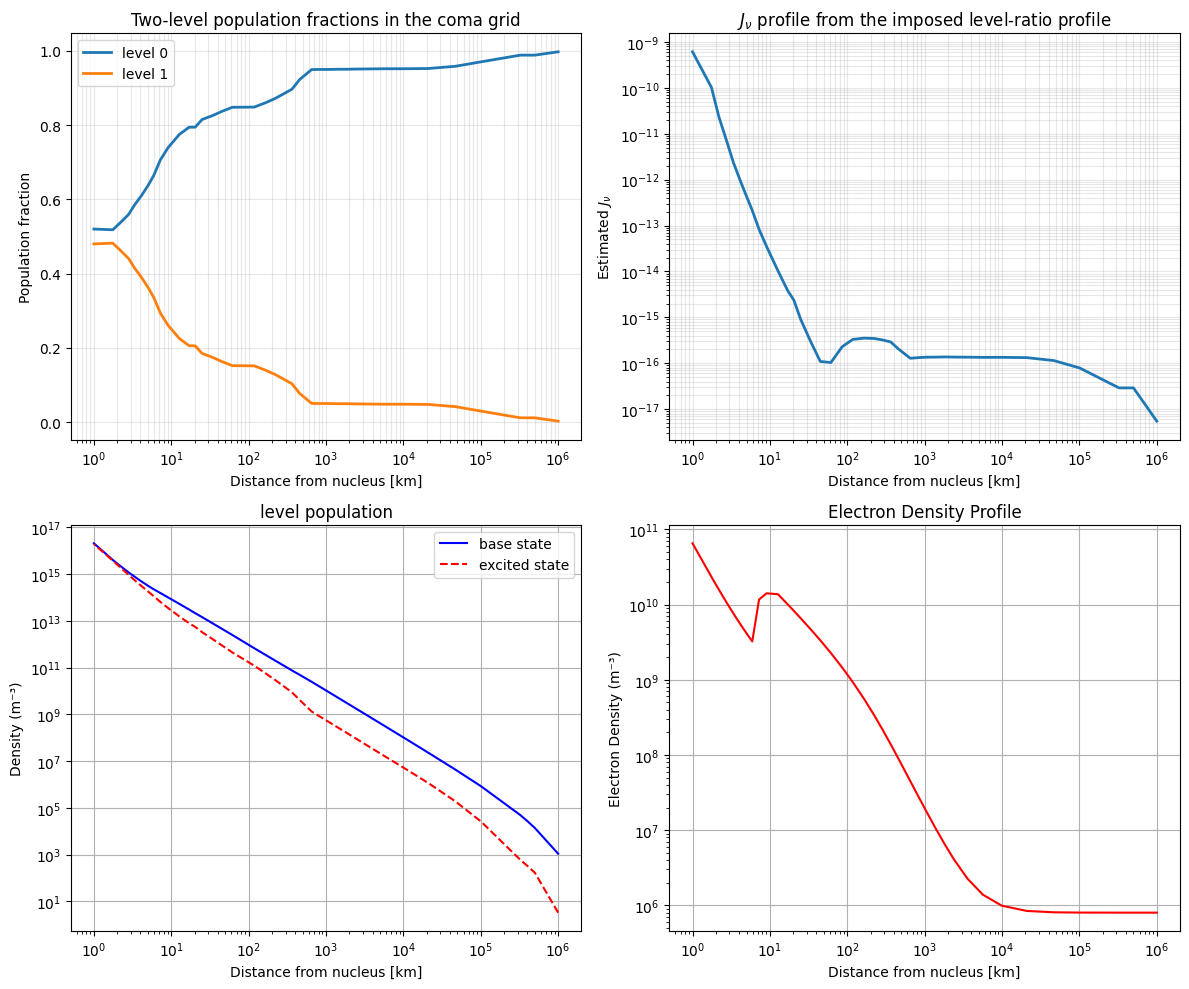

array([5.49363365e-18, 2.91212631e-17, 2.91212503e-17, 2.91212319e-17,
       7.90906923e-17, 1.14584121e-16, 1.33028440e-16, 1.34841277e-16,
       1.34725108e-16, 1.35879739e-16])

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ComaGrid import ComaGrid
from Einstein_coeff import einstein_coeffs_B
from Electron_collision import electron_collision_rate
from Molecular_collision import molecular_collision_rate
from Solar_pumping import scale_g_factors_from_1au
from profiles import (
    calc_density,
    electron_biver_1997,
    temperature_inverse_distance,
    velocity_tanh,
)

# Build the coma model on the same radial grid as the ratio profile.
xc = radius_km * 1.0e3
xf = np.empty(xc.size + 1, dtype=np.float64)
xf[1:-1] = np.sqrt(xc[:-1] * xc[1:])
xf[0] = xc[0] ** 2 / xf[1]
xf[-1] = xc[-1] ** 2 / xf[-2]

r_h = 2.5
v0 = 720.0
c_scale = 3.5e3
velocity = velocity_tanh(xc, v0=v0, c=c_scale)

T0 = 10.0
temperature = temperature_inverse_distance(xc, a=7, b=1, t0=T0, r0=2000)

Q = 1.0e26
density = calc_density(
    Q,
    xc,
    velocity,
    r_h=r_h,
    model_type="isotropic",
    photo_dissociation=True,
)

nelec, telec = electron_biver_1997(
    Q,
    r_h=r_h,
    r=xc,
    v=velocity,
    t_kin=temperature,
    t_emax=10000,
)

# Set the two-level populations from the supplied ratio profile.
# ComaGrid expects the excited-state fraction for level 1.
fractions = np.zeros((xc.size, 1), dtype=np.float64)
fractions[:, 0] = 1.0 - level0_ratio

coma = ComaGrid(temperature, density, velocity, nelec, telec, fractions)
coma.xf = xf
coma.xc = xc

n_l = coma.density[:, 0]
n_u = coma.density[:, 1]
level0_fraction = n_l / (n_l + n_u)
level1_fraction = n_u / (n_l + n_u)

# Transition and rate coefficients.
nu_Hz = 556.936e9
A_ul_s_1 = 3.456e-3
g_u = 9.0
g_l = 9.0
B_ul_SI, B_lu_SI = einstein_coeffs_B(
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
)

print(f"B_ul = {B_ul_SI:.3e} m^2 J^-1 s^-1")
print(f"B_lu = {B_lu_SI:.3e} m^2 J^-1 s^-1")

Cm_ul_s_1 = molecular_collision_rate(
    density,
    temperature,
)
electron_rates = np.array(
    [
        electron_collision_rate(
            n_e,
            t_e,
            nu_Hz=nu_Hz,
            A_ul_s_1=A_ul_s_1,
            g_u=g_u,
            g_l=g_l,
        )
        for n_e, t_e in zip(coma.nelec, coma.telec)
    ],
    dtype=np.float64,
)
Ce_ul_s_1 = electron_rates[:, 0]
Ce_lu_s_1 = electron_rates[:, 1]
G_ul_s_1, G_lu_s_1 = scale_g_factors_from_1au(
    heliocentric_distance_AU=r_h,
)
Cm_lu_s_1 = np.zeros_like(xc)

# Solve the statistical-equilibrium equation for J_nu in each layer:
# n_u (A_ul + B_ul J_nu + Cm_ul + Ce_ul + G_ul)
#   = n_l (B_lu J_nu + Cm_lu + Ce_lu + G_lu)
numerator = (
    n_u * (A_ul_s_1 + Cm_ul_s_1 + Ce_ul_s_1 + G_ul_s_1)
    - n_l * (Cm_lu_s_1 + Ce_lu_s_1 + G_lu_s_1)
)
denominator = n_l * B_lu_SI - n_u * B_ul_SI

J_nu = np.full_like(xc, np.nan, dtype=np.float64)
safe = np.abs(denominator) > 0.0
J_nu[safe] = numerator[safe] / denominator[safe]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
axes[0].plot(coma.xc * 1.0e-3, level0_fraction, lw=2, label="level 0")
axes[0].plot(coma.xc * 1.0e-3, level1_fraction, lw=2, label="level 1")
axes[0].set_xlabel("Distance from nucleus [km]")
axes[0].set_xscale("log")
axes[0].set_ylabel("Population fraction")
axes[0].set_title("Two-level population fractions in the coma grid")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].loglog(coma.xc * 1.0e-3, J_nu, lw=2)
# axes[1].set_xscale("log")
axes[1].set_xlabel("Distance from nucleus [km]")
axes[1].set_ylabel(r"Estimated $J_\nu$")
axes[1].set_title(r"$J_\nu$ profile from the imposed level-ratio profile")
axes[1].grid(True, which="both", alpha=0.3)

# level fraction at 0, and 1 level
axes[2].loglog(coma.xc * 1.0e-3, coma.density[:, 0], 'b-', label='base state')
axes[2].loglog(coma.xc * 1.0e-3, coma.density[:, 1], 'r--', label='excited state')
axes[2].set_xscale('log')
axes[2].set_xlabel('Distance from nucleus [km]')
axes[2].set_ylabel('Density (m⁻³)')
axes[2].set_title('level population')
axes[2].legend()
axes[2].grid()

axes[3].loglog(coma.xc * 1.0e-3, coma.nelec, label='Electron Density (m⁻³)', color='red')
# axes[3].set_xscale('log')
axes[3].set_xlabel('Distance from nucleus [km]')
axes[3].set_ylabel('Electron Density (m⁻³)')
axes[3].set_title('Electron Density Profile')
axes[3].grid()



plt.tight_layout()
plt.show()

J_nu[:10]


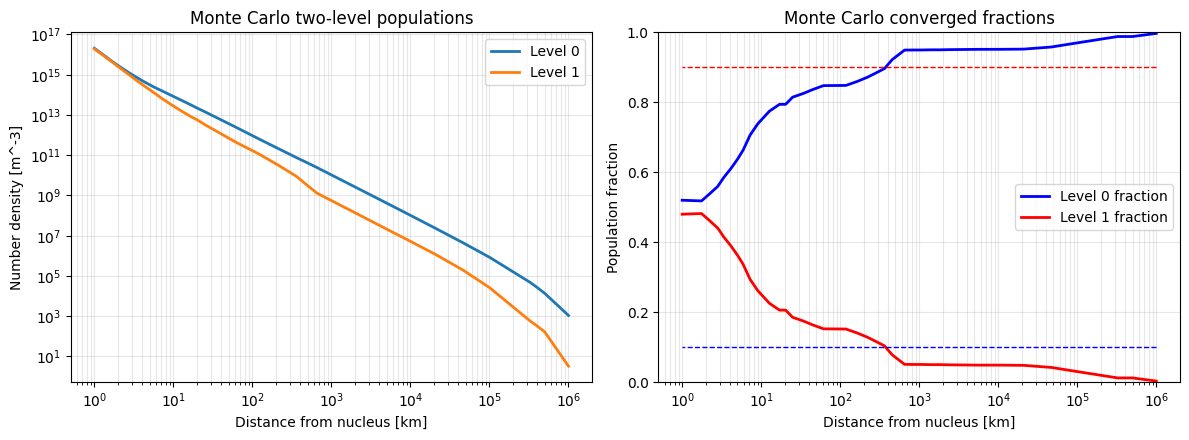

Iterations used: 113
All layers converged: True
Max relative residual: 9.976657549453741e-11


In [3]:
from Statistical_equilibrium import monte_carlo_two_level_populations

# Start from a deliberately neutral initial guess: 50% in level 0 and 50% in level 1.
# ComaGrid expects only excited-level fractions, so for a two-level system this is 0.5.
initial_excited_fraction = np.full((coma.ngrid, 1), 0.9, dtype=np.float64)

coma_mc = ComaGrid(
    temperature=np.array(coma.temperature, dtype=np.float64, copy=True),
    total_number_density=np.array(coma.total_number_density, dtype=np.float64, copy=True),
    velocity=np.array(coma.velocity, dtype=np.float64, copy=True),
    nelec=np.array(coma.nelec, dtype=np.float64, copy=True),
    telec=np.array(coma.telec, dtype=np.float64, copy=True),
    fractions=initial_excited_fraction,
)
coma_mc.xc = np.array(coma.xc, dtype=np.float64, copy=True)
coma_mc.xf = np.array(coma.xf, dtype=np.float64, copy=True)

mc_result = monte_carlo_two_level_populations(
    coma_mc,
    J_nu,
    A_ul_s_1=A_ul_s_1,
    B_ul_SI=B_ul_SI,
    B_lu_SI=B_lu_SI,
    Cm_ul_s_1=Cm_ul_s_1,
    Cm_lu_s_1=Cm_lu_s_1,
    Ce_ul_s_1=Ce_ul_s_1,
    Ce_lu_s_1=Ce_lu_s_1,
    G_ul_s_1=G_ul_s_1,
    G_lu_s_1=G_lu_s_1,
    nu_Hz=nu_Hz,
    g_u=g_u,
    g_l=g_l,
    lower_level=0,
    upper_level=1,
    max_iterations=20000,
    tolerance=1.0e-10,
    packet_fraction_range=(0.05, 0.35),
    random_seed=42,
)

r_km = coma_mc.xc * 1.0e-3
n0_mc = mc_result["n_lower"]
n1_mc = mc_result["n_upper"]
frac0_mc = n0_mc / np.maximum(n0_mc + n1_mc, np.finfo(np.float64).tiny)
frac1_mc = n1_mc / np.maximum(n0_mc + n1_mc, np.finfo(np.float64).tiny)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].loglog(r_km, n0_mc, lw=2, label="Level 0")
axes[0].loglog(r_km, n1_mc, lw=2, label="Level 1")
axes[0].set_xlabel("Distance from nucleus [km]")
axes[0].set_ylabel("Number density [m^-3]")
axes[0].set_title("Monte Carlo two-level populations")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].semilogx(r_km, frac0_mc, 'b', lw=2, label="Level 0 fraction")
axes[1].semilogx(r_km, frac1_mc, 'r', lw=2, label="Level 1 fraction")
axes[1].semilogx(r_km, 1-initial_excited_fraction[:, 0], 'b--', lw=1)
axes[1].semilogx(r_km, initial_excited_fraction[:, 0], 'r--', lw=1)

axes[1].set_ylim(0.0, 1.0)
axes[1].set_xlabel("Distance from nucleus [km]")
axes[1].set_ylabel("Population fraction")
axes[1].set_title("Monte Carlo converged fractions")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Iterations used:", mc_result["iterations_used"])
print("All layers converged:", bool(np.all(mc_result["converged"])))
print("Max relative residual:", float(np.max(mc_result["relative_residual"])))

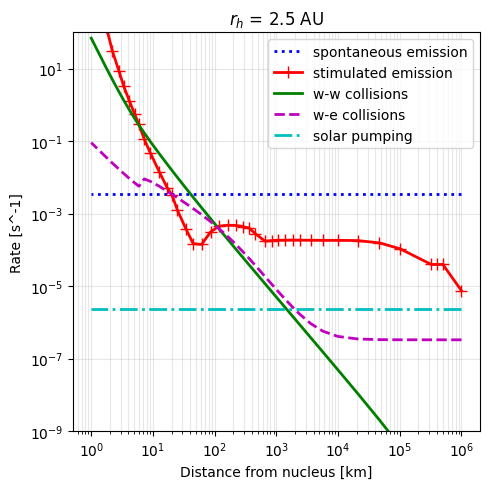

In [4]:
r_km = coma_mc.xc * 1.0e-3
A_profile = np.broadcast_to(np.asarray(A_ul_s_1, dtype=np.float64), r_km.shape)
stimulated_profile = np.asarray(B_ul_SI, dtype=np.float64) * J_nu
Cm_profile = np.broadcast_to(np.asarray(Cm_ul_s_1, dtype=np.float64), r_km.shape)
Ce_profile = np.broadcast_to(np.asarray(Ce_ul_s_1, dtype=np.float64), r_km.shape)
G_profile = np.broadcast_to(np.asarray(G_ul_s_1, dtype=np.float64), r_km.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.loglog(r_km, A_profile,'b:', lw=2,  label=r"spontaneous emission")
ax.loglog(r_km, stimulated_profile, 'r+-', lw=2, markersize=8, label=r"stimulated emission")
ax.loglog(r_km, Cm_profile, 'g-', lw=2, label=r"w-w collisions")
ax.loglog(r_km, Ce_profile, 'm--', lw=2, label=r"w-e collisions")
ax.loglog(r_km, G_profile, 'c-.', lw=2, label=r"solar pumping")
ax.set_ylim(1.0e-9, 1.0e2)
ax.set_xlabel("Distance from nucleus [km]")
ax.set_ylabel("Rate [s^-1]")
ax.set_title(r"$r_h$ = 2.5 AU")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


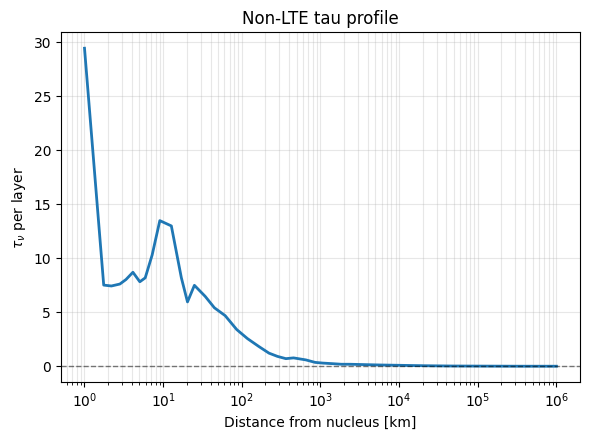

tau min: 9.657986100757716e-05
tau max: 29.456221637484845


In [5]:
from NonLTE_optics import nonlte_tau

ds_m = np.abs(np.diff(coma_mc.xf))
tau_profile = nonlte_tau(
    coma_mc,
    path_length_m=ds_m,
    lower_level=0,
    upper_level=1,
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
)

r_km = coma_mc.xc * 1.0e-3

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.semilogx(r_km, tau_profile, lw=2)
ax.axhline(0.0, color='k', ls='--', lw=1, alpha=0.5)
ax.set_xlabel("Distance from nucleus [km]")
ax.set_ylabel(r"$\tau_{\nu}$ per layer")
ax.set_title("Non-LTE tau profile")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print("tau min:", float(np.min(tau_profile)))
print("tau max:", float(np.max(tau_profile)))


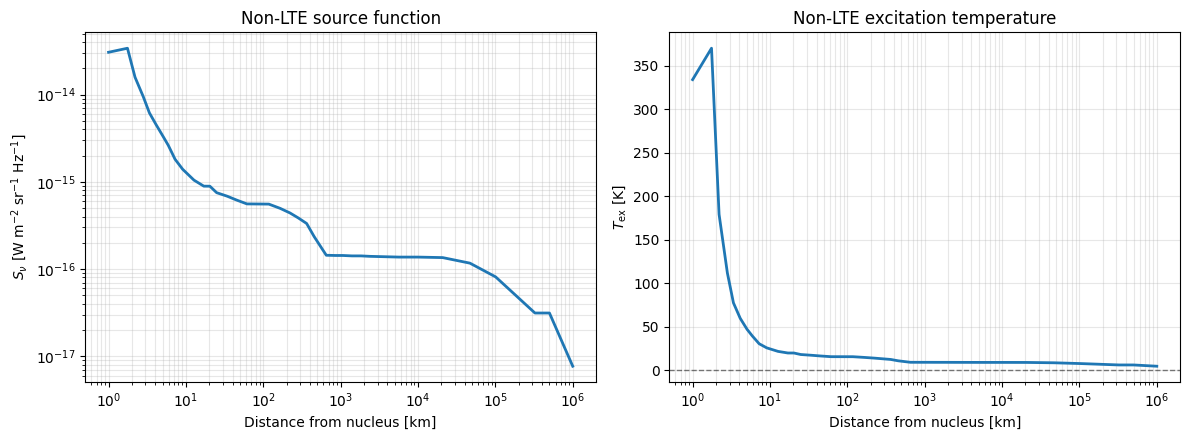

S_nu min: 7.687681411293956e-18
S_nu max: 3.4002742477469554e-14
T_ex min: 4.603526532132149
T_ex max: 370.0089274570353


In [6]:
from NonLTE_optics import nonlte_excitation_temperature, nonlte_source_function

source_profile = nonlte_source_function(
    coma_mc,
    lower_level=0,
    upper_level=1,
    nu_Hz=nu_Hz,
    g_u=g_u,
    g_l=g_l,
)

tex_profile = nonlte_excitation_temperature(
    coma_mc,
    lower_level=0,
    upper_level=1,
    nu_Hz=nu_Hz,
    g_u=g_u,
    g_l=g_l,
)

r_km = coma_mc.xc * 1.0e-3
finite_source = np.isfinite(source_profile) & (source_profile > 0.0)
finite_tex = np.isfinite(tex_profile)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

if np.any(finite_source):
    axes[0].loglog(r_km[finite_source], source_profile[finite_source], lw=2)
else:
    axes[0].text(0.5, 0.5, 'No positive finite values', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_xlabel("Distance from nucleus [km]")
axes[0].set_ylabel(r"$S_{\nu}$ [W m$^{-2}$ sr$^{-1}$ Hz$^{-1}$]")
axes[0].set_title("Non-LTE source function")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogx(r_km[finite_tex], tex_profile[finite_tex], lw=2)
axes[1].axhline(0.0, color='k', ls='--', lw=1, alpha=0.5)
axes[1].set_xlabel("Distance from nucleus [km]")
axes[1].set_ylabel(r"$T_{\mathrm{ex}}$ [K]")
axes[1].set_title("Non-LTE excitation temperature")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print("S_nu min:", float(np.nanmin(source_profile)))
print("S_nu max:", float(np.nanmax(source_profile)))
print("T_ex min:", float(np.nanmin(tex_profile)))
print("T_ex max:", float(np.nanmax(tex_profile)))


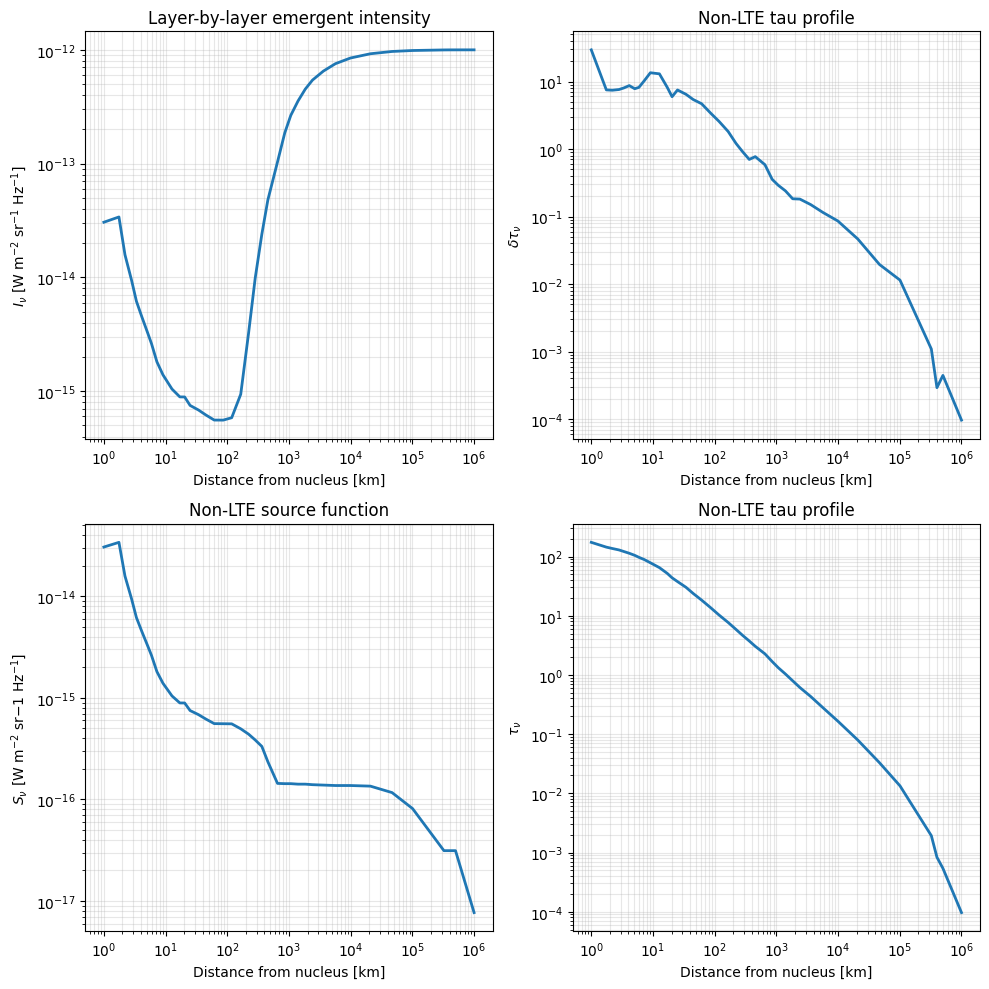

I_nu emergent: 3.056622046781251e-14
I_nu min: 5.575366973295029e-16
I_nu max: 9.999034255451164e-13


In [7]:
from RTsolver import solve_nlte_layers

rt_result = solve_nlte_layers(
    coma_mc,
    background_intensity=1E-12,
    lower_level=0,
    upper_level=1,
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
)

r_km = coma_mc.xc * 1.0e-3
intensity_profile = rt_result["intensity_out"]
finite_intensity = np.isfinite(intensity_profile) & (intensity_profile > 0.0)



fig, [[ax0, ax1], [ax2, ax3]] = plt.subplots(2,2, figsize=(10, 10))

ax0.loglog(r_km[finite_intensity], intensity_profile[finite_intensity], lw=2)

ax0.set_xlabel("Distance from nucleus [km]")
ax0.set_ylabel(r"$I_{\nu}$ [W m$^{-2}$ sr$^{-1}$ Hz$^{-1}$]")
ax0.set_title("Layer-by-layer emergent intensity")
ax0.grid(True, which="both", alpha=0.3)

tau=rt_result["tau_profile"]
finite_tau = np.isfinite(tau) & (tau > 0.0)
ax1.loglog(r_km[finite_tau], tau[finite_tau], lw=2)
ax1.set_xlabel("Distance from nucleus [km]")
ax1.set_ylabel(r"$\delta \tau_{\nu}$")
ax1.set_title("Non-LTE tau profile")
ax1.grid(True, which="both", alpha=0.3)

source_profile = rt_result["source_profile"]
finite_source = np.isfinite(source_profile) & (source_profile > 0.0)
ax2.loglog(r_km[finite_source], source_profile[finite_source], lw=2)
ax2.set_xlabel("Distance from nucleus [km]")
ax2.set_ylabel(r"$S_{\nu}$ [W m$^{-2}$ sr${-1}$ Hz$^{-1}$]")
ax2.set_title("Non-LTE source function")
ax2.grid(True, which="both", alpha=0.3)

tau=rt_result["cumulative_tau_traversed"]
finite_tau = np.isfinite(tau) & (tau > 0.0)
ax3.loglog(r_km[finite_tau], tau[finite_tau], lw=2)
ax3.set_xlabel("Distance from nucleus [km]")
ax3.set_ylabel(r"$\tau_{\nu}$")
ax3.set_title("Non-LTE tau profile")
ax3.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print("I_nu emergent:", float(rt_result["I_nu_emergent"]))
print("I_nu min:", float(np.nanmin(intensity_profile)))
print("I_nu max:", float(np.nanmax(intensity_profile)))
